Import all required Libraries  in the first python cell. 


In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report)
import warnings
warnings.filterwarnings("ignore")

import xgboost as xgb
import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras import models, layers, callbacks

print("All libraries imported successfully!")

All libraries imported successfully!


Load and read dataset and Display first 5 records

In [10]:
dataset_path = Path('dataset/train.csv')

try:
    df = pd.read_csv(dataset_path)
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print("\nFirst 5 rows:")
    display(df.head())
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully!
Shape: (593994, 13)

First 5 rows:


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


DATA EXPLORATION


DATA EXPLORATION
Dataset shape: (593994, 13)
Target unique values: [1. 0.]
Null values:
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64


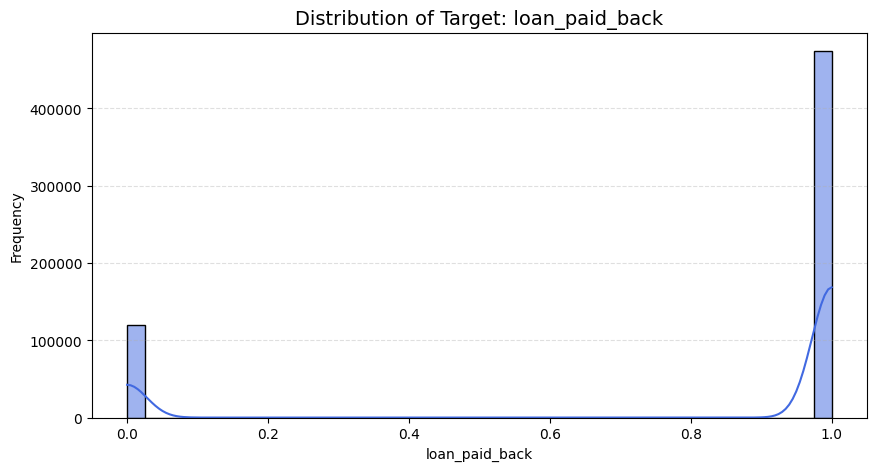


Target distribution:
loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64


In [11]:
print(f"\n{'='*60}")
print("DATA EXPLORATION")
print(f"{'='*60}")
print(f"Dataset shape: {df.shape}")
print(f"Target unique values: {df.loan_paid_back.unique()}")
print(f"Null values:\n{df.isnull().sum()}")

target = "loan_paid_back"
plt.figure(figsize=(10, 5))
sns.histplot(df[target], kde=True, bins=40, color="royalblue")
plt.title(f"Distribution of Target: {target}", fontsize=14)
plt.xlabel(target)
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

print(f"\nTarget distribution:")
print(df[target].value_counts(normalize=True))

HANDLE MISSING VALUES & OUTLIERS

In [12]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.median()))

num_cols_for_outlier = [col for col in num_cols if col != 'loan_paid_back']

Q1 = df[num_cols_for_outlier].quantile(0.25)
Q3 = df[num_cols_for_outlier].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df[num_cols_for_outlier] < lower_bound) | (df[num_cols_for_outlier] > upper_bound)
total_outliers = outlier_mask.sum().sum()
print(f"\nDetected {total_outliers} outlier values (IQR Method)")

mask = (df[num_cols_for_outlier] >= lower_bound) & (df[num_cols_for_outlier] <= upper_bound)
df = df[mask.all(axis=1)]

print(f"Data shape after outlier removal: {df.shape}")
print(f"Target distribution after outlier removal:")
print(df['loan_paid_back'].value_counts())

if df['loan_paid_back'].nunique() < 2:
    print("WARNING: Only one class remains! Skipping outlier removal.")
    df = pd.read_csv(dataset_path)
    df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.median()))



Detected 47412 outlier values (IQR Method)
Data shape after outlier removal: (548557, 13)
Target distribution after outlier removal:
loan_paid_back
1.0    445237
0.0    103320
Name: count, dtype: int64


FEATURE ENGINEERING

In [13]:
if 'id' in df.columns:
    df = df.drop(columns=['id'], axis=1)

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'loan_paid_back' in categorical_cols:
    categorical_cols.remove('loan_paid_back')

print(f"\nCategorical columns to encode: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Label encoding completed")


Categorical columns to encode: ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
Label encoding completed


train test split

In [14]:
X = df.drop('loan_paid_back', axis=1)
y = df['loan_paid_back']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTrain samples: {X_train.shape}")
print(f"Test samples: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")

# Save cleaned dataset structure and scaled datasets
joblib.dump(X.columns.tolist(), 'dataset_columns.pkl')
pd.DataFrame(X_train_scaled, columns=X.columns).to_csv('X_train_scaled.csv', index=False)
pd.DataFrame(X_test_scaled, columns=X.columns).to_csv('X_test_scaled.csv', index=False)
print("Saved: dataset_columns.pkl, X_train_scaled.csv, X_test_scaled.csv")



Train samples: (438845, 11)
Test samples: (109712, 11)
Feature scaling completed
Saved: dataset_columns.pkl, X_train_scaled.csv, X_test_scaled.csv


MODEL TRAINING WITH GRID SEARCH & CROSS-VALIDATION

In [15]:
def evaluate_model_with_cv(name, model, param_grid, X_train, X_test, y_train, y_test):
    """Train model with Grid Search and 5-Fold Cross-Validation"""
    print(f"\n{'='*60}")
    print(f"TRAINING: {name}")
    print(f"{'='*60}")
    
    # 5-Fold Cross-Validation
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Grid Search
    print(f"Running Grid Search with {len(param_grid)} parameter combinations...")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=kfold,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    # Best parameters
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    
    # Best model
    best_model = grid_search.best_estimator_
    
    # Cross-validation scores
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=kfold, scoring='accuracy')
    print(f"\nCross-Validation Scores: {cv_scores}")
    print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    # Test predictions
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"\nTest Set Performance:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return {
        'model': name,
        'best_model': best_model,
        'best_params': grid_search.best_params_,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc
    }

results = []

MODEL 1: RANDOM FOREST WITH GRID SEARCH


TRAINING: Random Forest
Running Grid Search with 4 parameter combinations...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score: 0.9093

Cross-Validation Scores: [0.90587793 0.91135822 0.90997961 0.90978592 0.90954665]
Mean CV Score: 0.9093 (+/- 0.0018)

Test Set Performance:
Accuracy:  0.9090
Precision: 0.9096
Recall:    0.9859
F1-Score:  0.9462
ROC-AUC:   0.9109


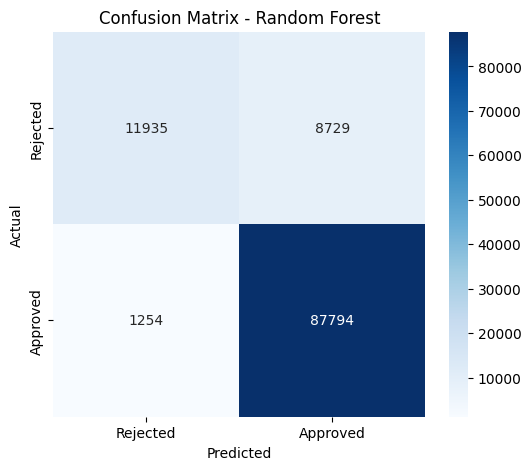

In [16]:
# Optimized Random Forest - Fast with 5-fold CV
rf_param_grid = {
    'n_estimators': [100],  # Single value for speed
    'max_depth': [20],  # Just one value
    'min_samples_split': [5],  # Just one value
    'min_samples_leaf': [2]  # Just one value
}

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_results = evaluate_model_with_cv(
    "Random Forest",
    rf_model,
    rf_param_grid,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
    # Remove cv=5 parameter
)
results.append(rf_results)

MODEL 2: XGBOOST WITH GRID SEARCH


TRAINING: XGBoost
Running Grid Search with 5 parameter combinations...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Best CV Score: 0.9101

Cross-Validation Scores: [0.90697171 0.9121102  0.91075437 0.91029862 0.91020748]
Mean CV Score: 0.9101 (+/- 0.0017)

Test Set Performance:
Accuracy:  0.9097
Precision: 0.9107
Recall:    0.9854
F1-Score:  0.9466
ROC-AUC:   0.9178


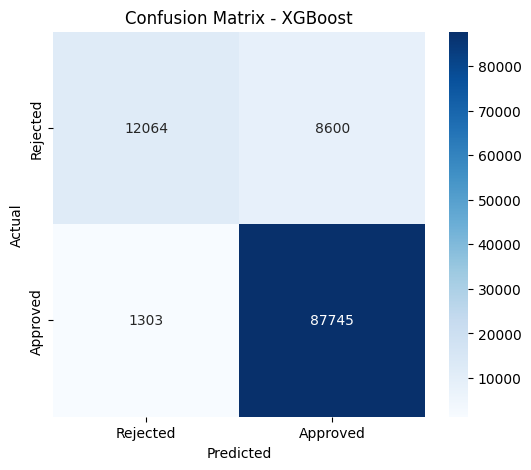

In [17]:
# Optimized XGBoost - Fast with 5-fold CV
xgb_param_grid = {
    'n_estimators': [100],  # Single value for speed
    'max_depth': [6],  # Just one value
    'learning_rate': [0.1],  # Just one value
    'subsample': [0.8],  # Just one value
    'colsample_bytree': [0.8]  # Just one value
}

xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_results = evaluate_model_with_cv(
    "XGBoost",
    xgb_model,
    xgb_param_grid,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    # Remove cv=5 parameter
)
results.append(xgb_results)

MODEL 3: LIGHTGBM WITH GRID SEARCH


TRAINING: LightGBM
Running Grid Search with 5 parameter combinations...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
Best CV Score: 0.9105

Cross-Validation Scores: [0.9071654  0.9122811  0.91170003 0.91062904 0.91056068]
Mean CV Score: 0.9105 (+/- 0.0018)

Test Set Performance:
Accuracy:  0.9104
Precision: 0.9107
Recall:    0.9863
F1-Score:  0.9470
ROC-AUC:   0.9170


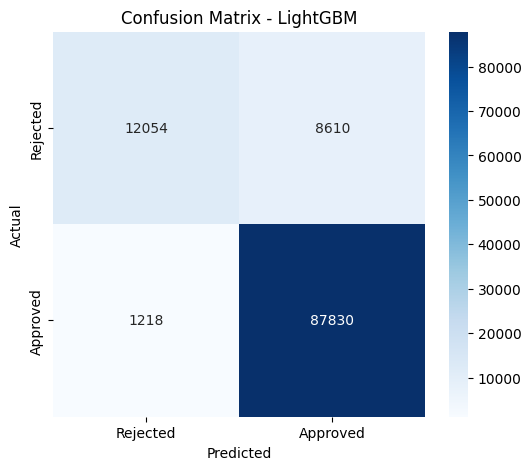

In [18]:
# Optimized LightGBM - Fast with 5-fold CV
lgb_param_grid = {
    'n_estimators': [100],  # Single value for speed
    'max_depth': [6],  # Just one value
    'learning_rate': [0.1],  # Just one value
    'num_leaves': [31],  # Just one value
    'subsample': [0.8]  # Just one value
}

lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgb_results = evaluate_model_with_cv(
    "LightGBM",
    lgb_model,
    lgb_param_grid,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    # Remove cv=5 parameter
)
results.append(lgb_results)

MODEL COMPARISON


MODEL COMPARISON


,Model,CV Mean,CV Std,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,LightGBM,0.910467,0.001775,0.910420,0.910722,0.986322,0.947015,0.917020
1,XGBoost,0.910068,0.001691,0.909736,0.910737,0.985367,0.946584,0.917800
0,Random Forest,0.909310,0.001828,0.909007,0.909566,0.985918,0.946204,0.910912


KeyError: 'Accuracy'

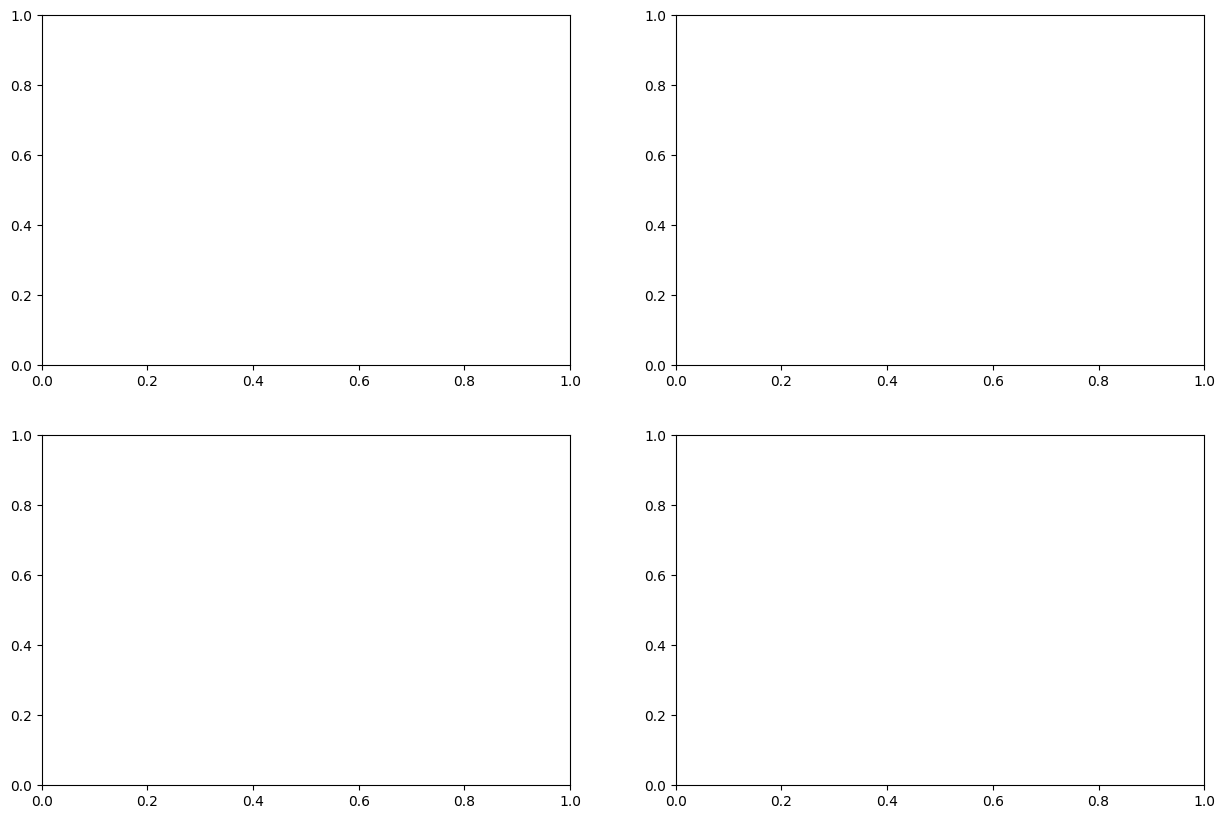

In [ ]:
print(f"\n{'='*60}")
print("MODEL COMPARISON")
print(f"{'='*60}")

comparison_df = pd.DataFrame([{
    'Model': r['model'],
    'CV Mean': r['cv_mean'],
    'CV Std': r['cv_std'],
    'Test Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'ROC-AUC': r['roc_auc']
} for r in results])

comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)
display(comparison_df)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Use the correct column names from the DataFrame
metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
titles = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    metric_data = comparison_df.sort_values(title)
    bars = ax.barh(metric_data['Model'], metric_data[title])
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    ax.set_xlabel(title)
    ax.set_xlim([0, 1])
    ax.set_title(f'{title} Comparison')
    for i, v in enumerate(metric_data[title]):
        ax.text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

SELECT AND SAVE BEST MODEL

In [ ]:
best_result = results[0]
for r in results:
    if r['accuracy'] > best_result['accuracy']:
        best_result = r

best_model_name = best_result['model']
best_model = best_result['best_model']
best_params = best_result['best_params']

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"Best Parameters: {best_params}")
print(f"{'='*60}")

# Save model
joblib.dump(best_model, 'backend/model.pkl')
print(f"Saved: model.pkl ({best_model_name}) to backend/")

# Save scaler
joblib.dump(scaler, 'backend/scaler.pkl')
print("Saved: scaler.pkl to backend/")

# Save label encoders
joblib.dump(label_encoders, 'backend/label_encoders.pkl')
print("Saved: label_encoders.pkl to backend/")

# Save feature names
joblib.dump(X_train.columns.tolist(), 'backend/feature_names.pkl')
print("Saved: feature_names.pkl to backend/")

# Save best parameters
joblib.dump(best_params, 'backend/best_hyperparameters.pkl')
print("Saved: best_hyperparameters.pkl to backend/")

print("\nALL MODEL FILES SAVED SUCCESSFULLY TO backend/ FOLDER!")


BASELINE PREDICTIONS

In [ ]:
print(f"\n{'='*60}")
print("BASELINE PREDICTIONS")
print(f"{'='*60}")

def create_test_sample(annual_income, debt_to_income_ratio, credit_score, 
                       loan_amount, interest_rate):
    """Create test sample with actual feature structure"""
    test_data = {}
    test_data['annual_income'] = annual_income
    test_data['debt_to_income_ratio'] = debt_to_income_ratio
    test_data['credit_score'] = credit_score
    test_data['loan_amount'] = loan_amount
    test_data['interest_rate'] = interest_rate
    
    for col in X_train.columns:
        if col not in test_data:
            test_data[col] = X_train[col].median()
    
    return test_data

test_samples = [
    {
        'name': 'Excellent Applicant',
        'annual_income': 10000000,
        'debt_to_income_ratio': 0.20,
        'credit_score': 780,
        'loan_amount': 2000000,
        'interest_rate': 7.0,
        'expected': 'APPROVED'
    },
    {
        'name': 'Good Applicant',
        'annual_income': 6000000,
        'debt_to_income_ratio': 0.35,
        'credit_score': 700,
        'loan_amount': 1500000,
        'interest_rate': 9.5,
        'expected': 'APPROVED'
    },
    {
        'name': 'Medium Risk Applicant',
        'annual_income': 4000000,
        'debt_to_income_ratio': 0.50,
        'credit_score': 620,
        'loan_amount': 2500000,
        'interest_rate': 13.0,
        'expected': 'UNCERTAIN'
    },
    {
        'name': 'High Risk Applicant',
        'annual_income': 2500000,
        'debt_to_income_ratio': 0.75,
        'credit_score': 500,
        'loan_amount': 3000000,
        'interest_rate': 16.5,
        'expected': 'REJECTED'
    },
    {
        'name': 'Bad Applicant',
        'annual_income': 1500000,
        'debt_to_income_ratio': 0.90,
        'credit_score': 400,
        'loan_amount': 5000000,
        'interest_rate': 20.0,
        'expected': 'REJECTED'
    }
]

baseline_results = []

for sample in test_samples:
    test_data = create_test_sample(
        annual_income=sample['annual_income'],
        debt_to_income_ratio=sample['debt_to_income_ratio'],
        credit_score=sample['credit_score'],
        loan_amount=sample['loan_amount'],
        interest_rate=sample['interest_rate']
    )
    
    test_df = pd.DataFrame([test_data])[X_train.columns]
    test_scaled = scaler.transform(test_df)
    
    pred_class = best_model.predict(test_scaled)[0]
    probability = best_model.predict_proba(test_scaled)[0][1]
    
    result = "APPROVED" if pred_class == 1 else "REJECTED"
    
    baseline_results.append({
        'Applicant': sample['name'],
        'Income (RWF)': f"{sample['annual_income']:,}",
        'Loan (RWF)': f"{sample['loan_amount']:,}",
        'Credit Score': sample['credit_score'],
        'DTI Ratio': f"{sample['debt_to_income_ratio']:.1%}",
        'Interest Rate': f"{sample['interest_rate']}%",
        'Prediction': result,
        'Confidence': f"{probability:.1%}",
        'Expected': sample['expected']
    })

baseline_df = pd.DataFrame(baseline_results)
display(baseline_df)

# Save baseline predictions
baseline_df.to_csv('backend/baseline_predictions.csv', index=False)
print("\nSaved: baseline_predictions.csv to backend/")

print(f"\n{'='*60}")
print("TRAINING & BASELINE PREDICTIONS COMPLETE!")
print("All files saved to backend/ folder")
print(f"{'='*60}")